<a href="https://colab.research.google.com/github/eduardonrpinto/Diffusion_Huggingface/blob/main/DiffusionScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Install necessary libraries**

In [1]:
pip install -q diffusers

In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


## **Load the Data**

This command downloads MNIST data set and converts him into a tensor


In [3]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 455kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.46MB/s]


Splits the data sets into batches for training

In [5]:
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

Call first batch and display it

Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([6, 7, 4, 9, 6, 0, 8, 3])


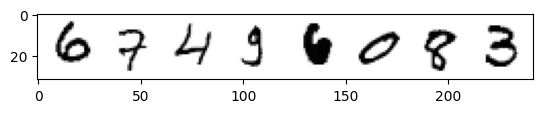

In [8]:
images, label = next(iter(train_dataloader)) # gets the first batch
print('Input shape:', images.shape)
print('Labels:', label)
plt.imshow(torchvision.utils.make_grid(images)[0], cmap='Greys');


## **Create DDPM noise scheduler**

Original: torch.Size([8, 1, 28, 28])
Noisy: torch.Size([8, 1, 28, 28])
Noise: torch.Size([8, 1, 28, 28])
Timesteps: tensor([390, 775, 445, 343, 863, 120, 453,  55])


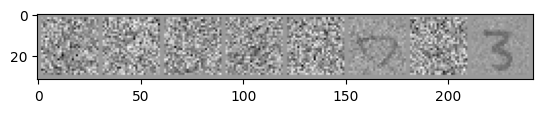

In [10]:
import torch


class DDPMScheduler:

    def __init__(
        self,
        num_train_timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
    ):
        self.num_train_timesteps = num_train_timesteps

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            num_train_timesteps
        )

        self.alphas = 1.0 - self.betas

        self.alpha_bars = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.sqrt_alpha_bars = torch.sqrt(
            self.alpha_bars
        )

        self.sqrt_one_minus_alpha_bars = torch.sqrt(
            1.0 - self.alpha_bars
        )

    def add_noise(self, x_0, t, noise=None):

        if noise is None:
            noise = torch.randn_like(x_0)

        sqrt_alpha_bar = self.sqrt_alpha_bars[t]
        sqrt_one_minus_alpha_bar = (
            self.sqrt_one_minus_alpha_bars[t]
        )

        sqrt_alpha_bar = sqrt_alpha_bar.view(
            -1, 1, 1, 1
        )

        sqrt_one_minus_alpha_bar = (
            sqrt_one_minus_alpha_bar.view(
                -1, 1, 1, 1
            )
        )

        x_t = (
            sqrt_alpha_bar * x_0
            + sqrt_one_minus_alpha_bar * noise
        )

        return x_t, noise


# Create scheduler
scheduler = DDPMScheduler()

# Get a batch
images, labels = next(iter(train_dataloader))

# Pick random timestep for each image
t = torch.randint(
    0,
    scheduler.num_train_timesteps,
    (images.shape[0],)
)

# Add noise
noisy_images, noise = scheduler.add_noise(
    images,
    t
)

print("Original:", images.shape)
print("Noisy:", noisy_images.shape)
print("Noise:", noise.shape)
print("Timesteps:", t)
plt.imshow(torchvision.utils.make_grid(noisy_images)[0], cmap='Greys');

## **Define the U-Net**

In [18]:
import torch
import torch.nn as nn
import math


class BasicUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, time_dim=32):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim))

        self.down_layers = nn.ModuleList([
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),])

        self.time_down = nn.ModuleList([
            nn.Linear(time_dim, 32),
            nn.Linear(time_dim, 64),
            nn.Linear(time_dim, 64),])

        self.up_layers = nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2),])

        self.time_up = nn.ModuleList([
            nn.Linear(time_dim, 64),
            nn.Linear(time_dim, 32),
            nn.Linear(time_dim, out_channels),])

        self.act = nn.SiLU()
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(
            scale_factor=2,
            mode="nearest")

    def forward(self, x, t):
        t = t.float().view(-1, 1)
        t_emb = self.time_mlp(t)

        h = []

        for i, layer in enumerate(self.down_layers):
            x = layer(x)
            time_emb = self.time_down[i](t_emb)


            time_emb = time_emb[:, :, None, None]

            x = x + time_emb

            x = self.act(x)

            if i < 2:
                h.append(x)
                x = self.downscale(x)

        for i, layer in enumerate(self.up_layers):

            if i > 0:
                x = self.upscale(x)
                x = x + h.pop()

            x = layer(x)
            time_emb = self.time_up[i](t_emb)
            time_emb = time_emb[:, :, None, None]

            x = x + time_emb
            x = self.act(x)

        return x

## **Train the U-Net to predict the noise**

Finished epoch 0. Average loss for this epoch: 1.439646
Finished epoch 1. Average loss for this epoch: 0.999968
Finished epoch 2. Average loss for this epoch: 1.000024


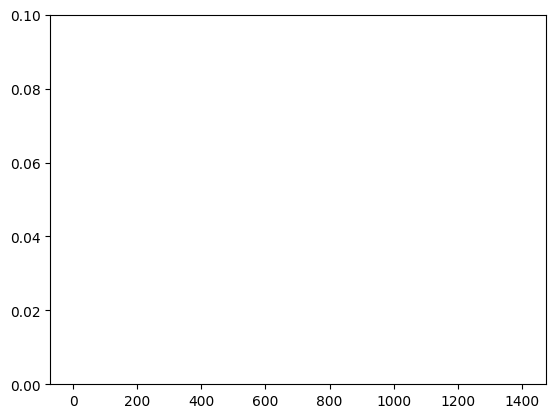

In [21]:
batch_size = 128
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
net = BasicUNet()
n_epochs = 3
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
losses = []

for epoch in range(n_epochs):

    for x, y in train_dataloader:

        x = x.to(device)
        t = torch.randint(
            0,
            scheduler.num_train_timesteps,
            (x.shape[0],),
            device=device)
        noise = torch.randn_like(x)
        noisy_x, noise = scheduler.add_noise(
            x,
            t,
            noise
        )
        pred_noise = net(noisy_x, t)
        loss = loss_fn(pred_noise, noise)

        opt.zero_grad()

        loss.backward()

        opt.step()

        losses.append(loss.item())
    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1);
